In [1]:
import os
import random
import shutil
import numpy as np
import tensorflow as tf

#Sonuçların her seferinde aynı çıkması için sabitliyoruz
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Orijinal veri yolları
base_train_dir = "fruits-360/Training"
base_test_dir = "fruits-360/Test"

# Yeni, temiz proje klasörleri
new_train_dir = "fruits_small_train"
new_test_dir = "fruits_small_test"

#Eski klasörler varsa siliyoruz karışıklık olmasın
if os.path.exists(new_train_dir):
    shutil.rmtree(new_train_dir)
if os.path.exists(new_test_dir):
    shutil.rmtree(new_test_dir)

os.makedirs(new_train_dir, exist_ok=True)
os.makedirs(new_test_dir, exist_ok=True)

# Tüm sınıfları al ve rastgele 15 tanesini seç
all_classes = os.listdir(base_train_dir)
selected_classes = random.sample(all_classes, 15)

print("Seçilen 15 Sınıf:", selected_classes)
print("-" * 50)

# Seçilen sınıfların fotoğraflarını yeni klasörlere kopyala
for cls in selected_classes:
    print(f"{cls} kopyalanıyor...")
    
    # 1. TRAIN İÇİN KOPYALAMA (150 Fotoğraf)
    src_train = os.path.join(base_train_dir, cls)
    dst_train = os.path.join(new_train_dir, cls)
    os.makedirs(dst_train, exist_ok=True)
    
    train_images = os.listdir(src_train)
    selected_train = random.sample(train_images, min(150, len(train_images))) 
    for img in selected_train:
        shutil.copy(os.path.join(src_train, img), os.path.join(dst_train, img))
        
    # 2. TEST İÇİN KOPYALAMA (50 Fotoğraf)
    src_test = os.path.join(base_test_dir, cls)
    dst_test = os.path.join(new_test_dir, cls)
    os.makedirs(dst_test, exist_ok=True)
    
    test_images = os.listdir(src_test)
    selected_test = random.sample(test_images, min(50, len(test_images))) 
    for img in selected_test:
        shutil.copy(os.path.join(src_test, img), os.path.join(dst_test, img))

print("-" * 50)
print("Kopyalama işlemi başarıyla tamamlandı!")

Seçilen 15 Sınıf: ['Cantaloupe 2', 'Apple 23', 'Nut 4', 'Limes 1', 'Grapefruit Pink 1', 'Cherry Rainier 3', 'Cactus fruit 1', 'Blackberry 1', 'Quince 3', 'Apple 8', 'Apple 7', 'BlackBerry 4', 'Grape White 2', 'Kaki 1', 'Apple 5']
--------------------------------------------------
Cantaloupe 2 kopyalanıyor...
Apple 23 kopyalanıyor...
Nut 4 kopyalanıyor...
Limes 1 kopyalanıyor...
Grapefruit Pink 1 kopyalanıyor...
Cherry Rainier 3 kopyalanıyor...
Cactus fruit 1 kopyalanıyor...
Blackberry 1 kopyalanıyor...
Quince 3 kopyalanıyor...
Apple 8 kopyalanıyor...
Apple 7 kopyalanıyor...
BlackBerry 4 kopyalanıyor...
Grape White 2 kopyalanıyor...
Kaki 1 kopyalanıyor...
Apple 5 kopyalanıyor...
--------------------------------------------------
Kopyalama işlemi başarıyla tamamlandı!


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Yeni oluşturduğumuz yollar
train_path = 'fruits_small_train'
test_path = 'fruits_small_test'

# Sadece eğitim seti için veri çoğaltma (Data Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

# Test seti için sadece ölçekleme (Rescale)
test_datagen = ImageDataGenerator(rescale=1./255)

#TRAIN GENERATOR
train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical'
)

#VALIDATION GENERATOR
val_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical'
)

#TEST GENERATOR (Confusion Matrix için - SHUFFLE=FALSE)
val_gen_no_shuffle = test_datagen.flow_from_directory(
    test_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)

print("-" * 50)
print(f"Sınıf sayısı: {len(train_gen.class_indices)}")
print(f"Toplam eğitim görüntüsü: {train_gen.samples}")
print(f"Toplam test görüntüsü: {val_gen_no_shuffle.samples}")

Found 2250 images belonging to 15 classes.
Found 750 images belonging to 15 classes.
Found 750 images belonging to 15 classes.
--------------------------------------------------
Sınıf sayısı: 15
Toplam eğitim görüntüsü: 2250
Toplam test görüntüsü: 750


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization

def create_fruit_model(optimizer_name, num_classes):
    model = Sequential([
        Input(shape=(64, 64, 3)),

        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])

    #cite: 1
    if optimizer_name == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=0.001)
    elif optimizer_name == 'adagrad':
        opt = tf.keras.optimizers.Adagrad(learning_rate=0.01)
    elif optimizer_name == 'adamax':
        opt = tf.keras.optimizers.Adamax(learning_rate=0.002)
    elif optimizer_name == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    else:
        opt = optimizer_name

    model.compile(
        optimizer=opt, # Artık sadece isim değil, ayarlanmış nesne gidiyor
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Sınıf sayısını (train_gen oluşturulduktan sonra) al
num_classes = len(train_gen.class_indices)

# Modeli oluştur
temp_model = create_fruit_model('adam', num_classes)

# Özeti ekrana bas
print("Model başarıyla oluşturuldu. Mimari özet aşağıdadır:\n")
temp_model.summary()

Model başarıyla oluşturuldu. Mimari özet aşağıdadır:



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,118,991 (8.08 MB)

 Trainable params: 2,118,799 (8.08 MB)

 Non-trainable params: 192 (768.00 B)

In [4]:
import time

optimizers = ['adam', 'adagrad', 'adamax', 'sgd']
histories = {}
models = {}  # Eğitilmiş modellerin kendisini saklıyoruz
execution_times = {} #Dinamik süre analizi için yeni sözlük
best_model = None
best_acc = 0

for opt in optimizers:
    print(f"\n>>> {opt.upper()} eğitiliyor...")
    
    # Zamanlayıcıyı başlat
    start_time = time.time()

    model = create_fruit_model(opt, len(train_gen.class_indices))

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        verbose=1
    )
    
    # Bitiş zamanını al ve saniye olarak farkı kaydet
    end_time = time.time()
    execution_times[opt.upper()] = int(end_time - start_time)

    # Hem geçmişi (grafikler için) hem de modeli (matris için) kaydet
    histories[opt] = history
    models[opt] = model  

    #en iyi epoch
    val_acc = max(history.history['val_accuracy'])
    print(f"{opt.upper()} best val_acc: {val_acc}")

    if val_acc > best_acc:
        best_acc = val_acc
        best_model = model

print("\nEĞİTİM BİTTİ. EN İYİ MODEL SEÇİLDİ VE TÜM MODELLER HAFIZAYA ALINDI!")


>>> ADAM eğitiliyor...
Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 32s 424ms/step - accuracy: 0.4409 - loss: 2.2098 - val_accuracy: 0.0667 - val_loss: 9.4026
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 200ms/step - accuracy: 0.6560 - loss: 1.0387 - val_accuracy: 0.0667 - val_loss: 17.3290
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 209ms/step - accuracy: 0.7484 - loss: 0.7471 - val_accuracy: 0.0667 - val_loss: 23.3700
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 205ms/step - accuracy: 0.8196 - loss: 0.5378 - val_accuracy: 0.1840 - val_loss: 17.3734
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 209ms/step - accuracy: 0.8329 - loss: 0.4830 - val_accuracy: 0.2480 - val_loss: 13.9075
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 210ms/step - accuracy: 0.8791 - loss: 0.3435 - val_accuracy: 0.4133 - val_loss: 4.7816
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 209ms/step - accuracy: 0.8920 - loss: 0.3302 - val_accuracy: 0.9347 - val_loss: 0.1793
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 208ms/step - accuracy: 0.89

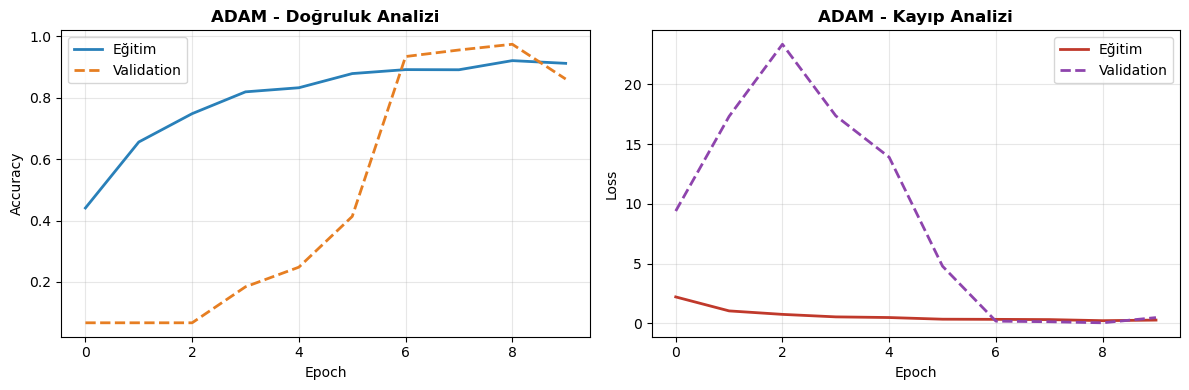

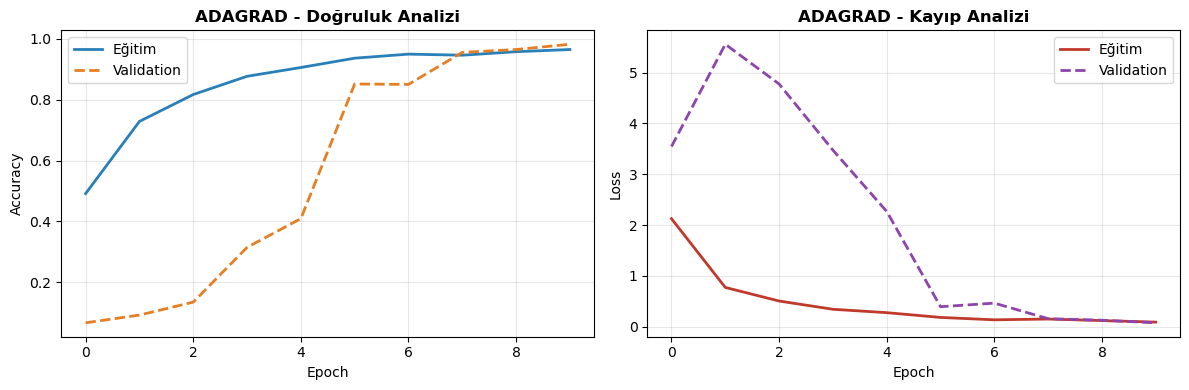

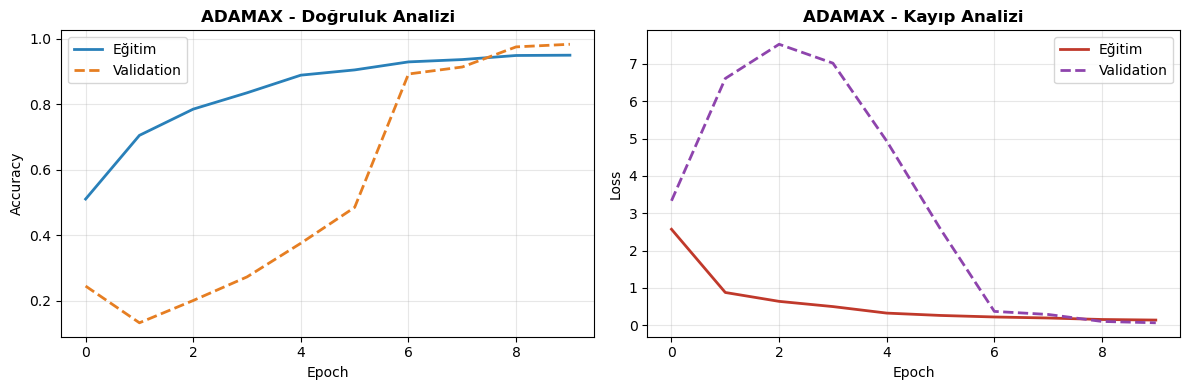

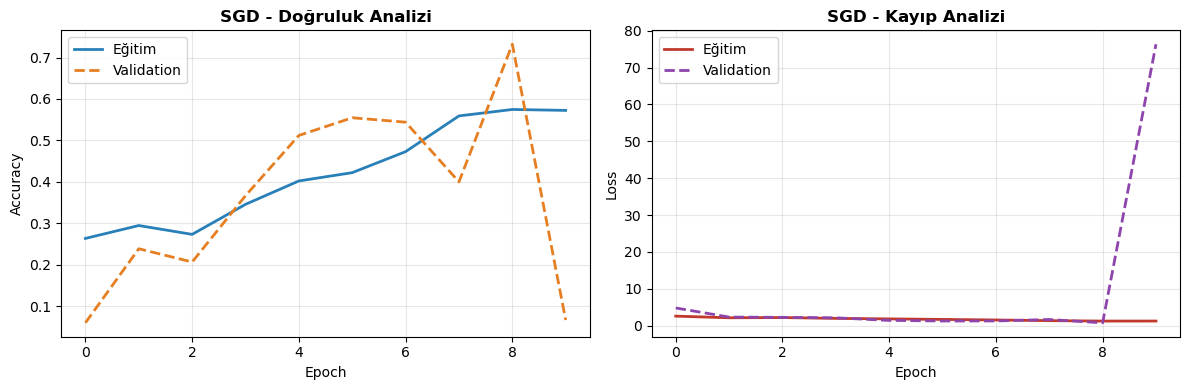

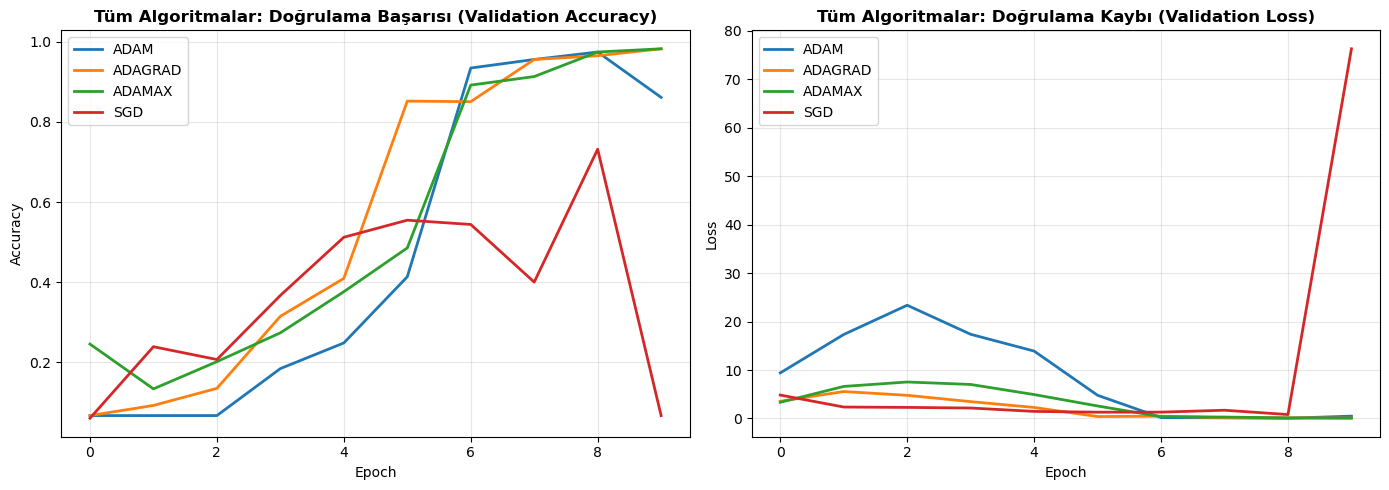

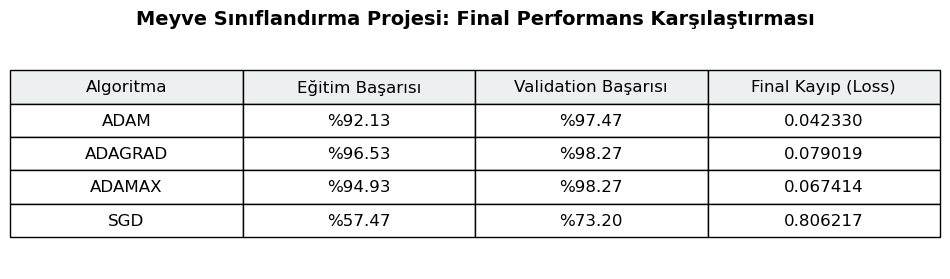

In [5]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. BÖLÜM: HER ALGORİTMA İÇİN AYRI AYRI ANALİZ 
for opt in histories:
    # Her algoritma için yeni, temiz bir figür yarat (12x4 boyutunda)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Accuracy (Doğruluk) Grafiği
    ax1.plot(histories[opt].history['accuracy'], label='Eğitim', color='#2980b9', linewidth=2)
    ax1.plot(histories[opt].history['val_accuracy'], label='Validation', color='#e67e22', linestyle='--', linewidth=2)
    ax1.set_title(f"{opt.upper()} - Doğruluk Analizi", fontweight='bold')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Loss (Kayıp) Grafiği
    ax2.plot(histories[opt].history['loss'], label='Eğitim', color='#c0392b', linewidth=2)
    ax2.plot(histories[opt].history['val_loss'], label='Validation', color='#8e44ad', linestyle='--', linewidth=2)
    ax2.set_title(f"{opt.upper()} - Kayıp Analizi", fontweight='bold')
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show() # Her algoritmadan sonra grafiği bas ve kapat

# ---------------------------------------------------------

# 2. BÖLÜM: TÜM ALGORİTMALARIN BİRLEŞİK KIYASLAMASI 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Doğrulama Başarısı Kıyaslaması
for opt in histories:
    ax1.plot(histories[opt].history['val_accuracy'], label=f'{opt.upper()}', linewidth=2)
ax1.set_title("Tüm Algoritmalar: Doğrulama Başarısı (Validation Accuracy)", fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Doğrulama Kaybı Kıyaslaması
for opt in histories:
    ax2.plot(histories[opt].history['val_loss'], label=f'{opt.upper()}', linewidth=2)
ax2.set_title("Tüm Algoritmalar: Doğrulama Kaybı (Validation Loss)", fontweight='bold')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------

# 3. BÖLÜM: GÖRSEL PERFORMANS TABLOSU 
final_results = []
for opt in histories:
    # [-1] ile son epoch'u almak yerine, max() ve min() ile ulaşılan en iyi değerleri alıyoruz
    best_train_acc = max(histories[opt].history['accuracy'])
    best_val_acc = max(histories[opt].history['val_accuracy'])
    best_val_loss = min(histories[opt].history['val_loss'])
    
    final_results.append({
        'Algoritma': opt.upper(),
        'Eğitim Başarısı': f"%{best_train_acc*100:.2f}",
        'Validation Başarısı': f"%{best_val_acc*100:.2f}",
        'Final Kayıp (Loss)': f"{best_val_loss:.6f}"
    })

df_final = pd.DataFrame(final_results)

# Görsel tabloyu oluşturma
plt.figure(figsize=(10, 3))
plt.axis('off')
final_table = plt.table(cellText=df_final.values, colLabels=df_final.columns, 
                        cellLoc='center', loc='center', colColours=['#ecf0f1']*4)
final_table.auto_set_font_size(False)
final_table.set_fontsize(12)
final_table.scale(1.2, 2.0)
plt.title("Meyve Sınıflandırma Projesi: Final Performans Karşılaştırması", fontsize=14, fontweight='bold', pad=10)
plt.show()


   ADAM ALGORİTMASI İÇİN CONFUSION MATRIX VE SINIFLANDIRMA RAPORU
ADAM ile test seti üzerinde tahminler alınıyor. Lütfen bekleyin...



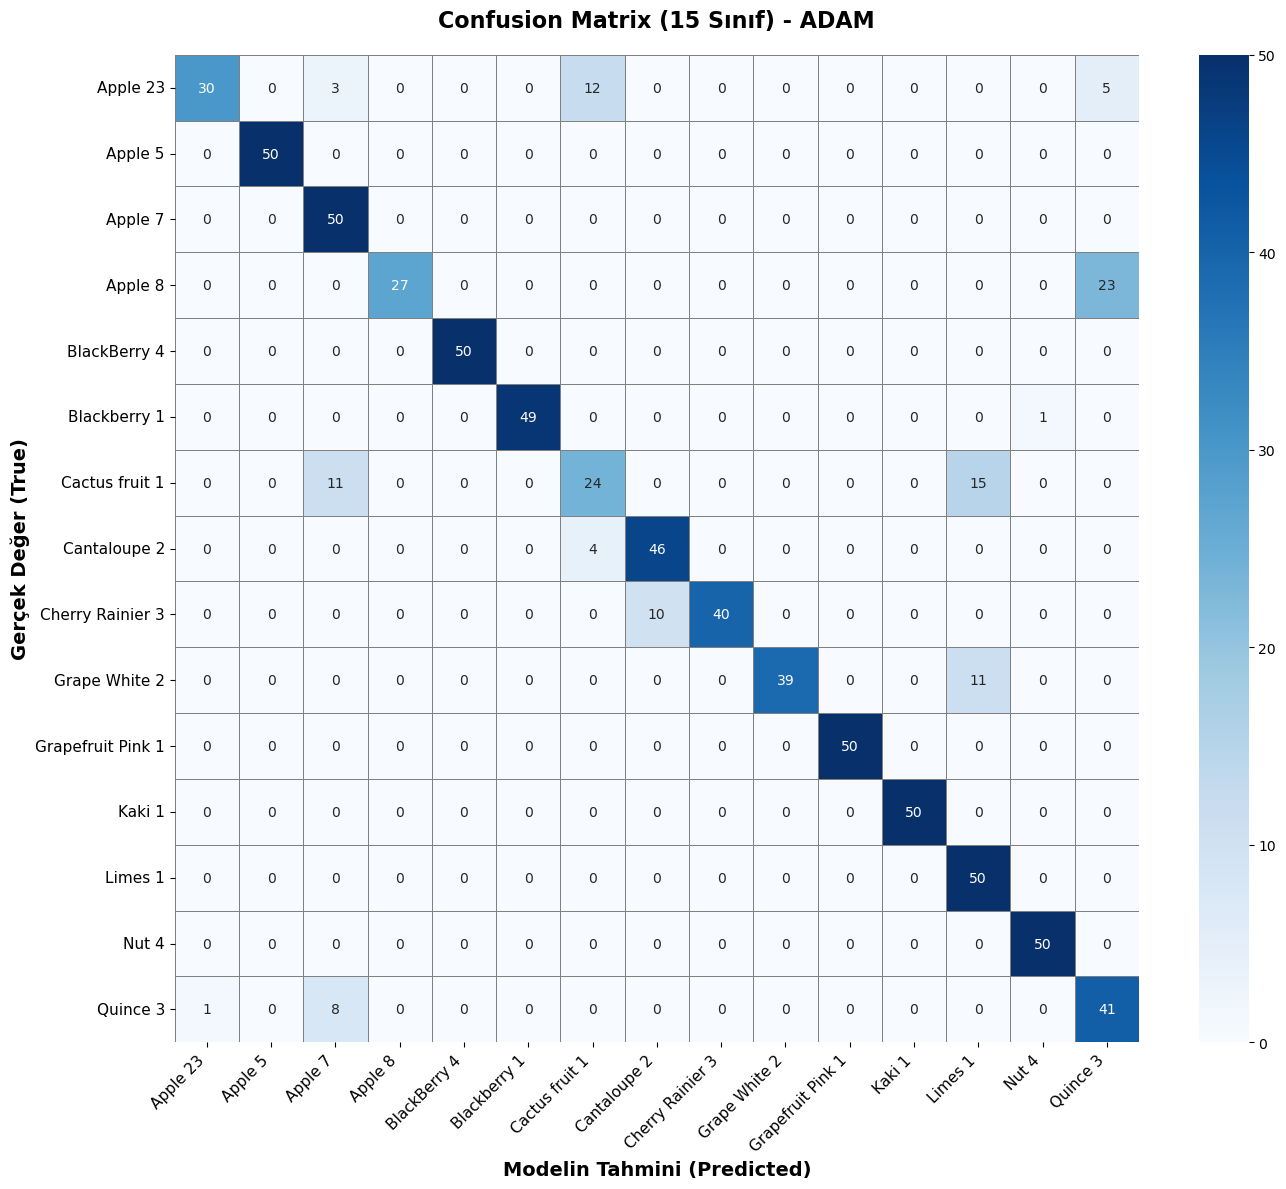


--- ADAM İÇİN DETAYLI SINIFLANDIRMA RAPORU ---
                   precision    recall  f1-score   support

         Apple 23       0.97      0.60      0.74        50
          Apple 5       1.00      1.00      1.00        50
          Apple 7       0.69      1.00      0.82        50
          Apple 8       1.00      0.54      0.70        50
     BlackBerry 4       1.00      1.00      1.00        50
     Blackberry 1       1.00      0.98      0.99        50
   Cactus fruit 1       0.60      0.48      0.53        50
     Cantaloupe 2       0.82      0.92      0.87        50
 Cherry Rainier 3       1.00      0.80      0.89        50
    Grape White 2       1.00      0.78      0.88        50
Grapefruit Pink 1       1.00      1.00      1.00        50
           Kaki 1       1.00      1.00      1.00        50
          Limes 1       0.66      1.00      0.79        50
            Nut 4       0.98      1.00      0.99        50
         Quince 3       0.59      0.82      0.69        50

      

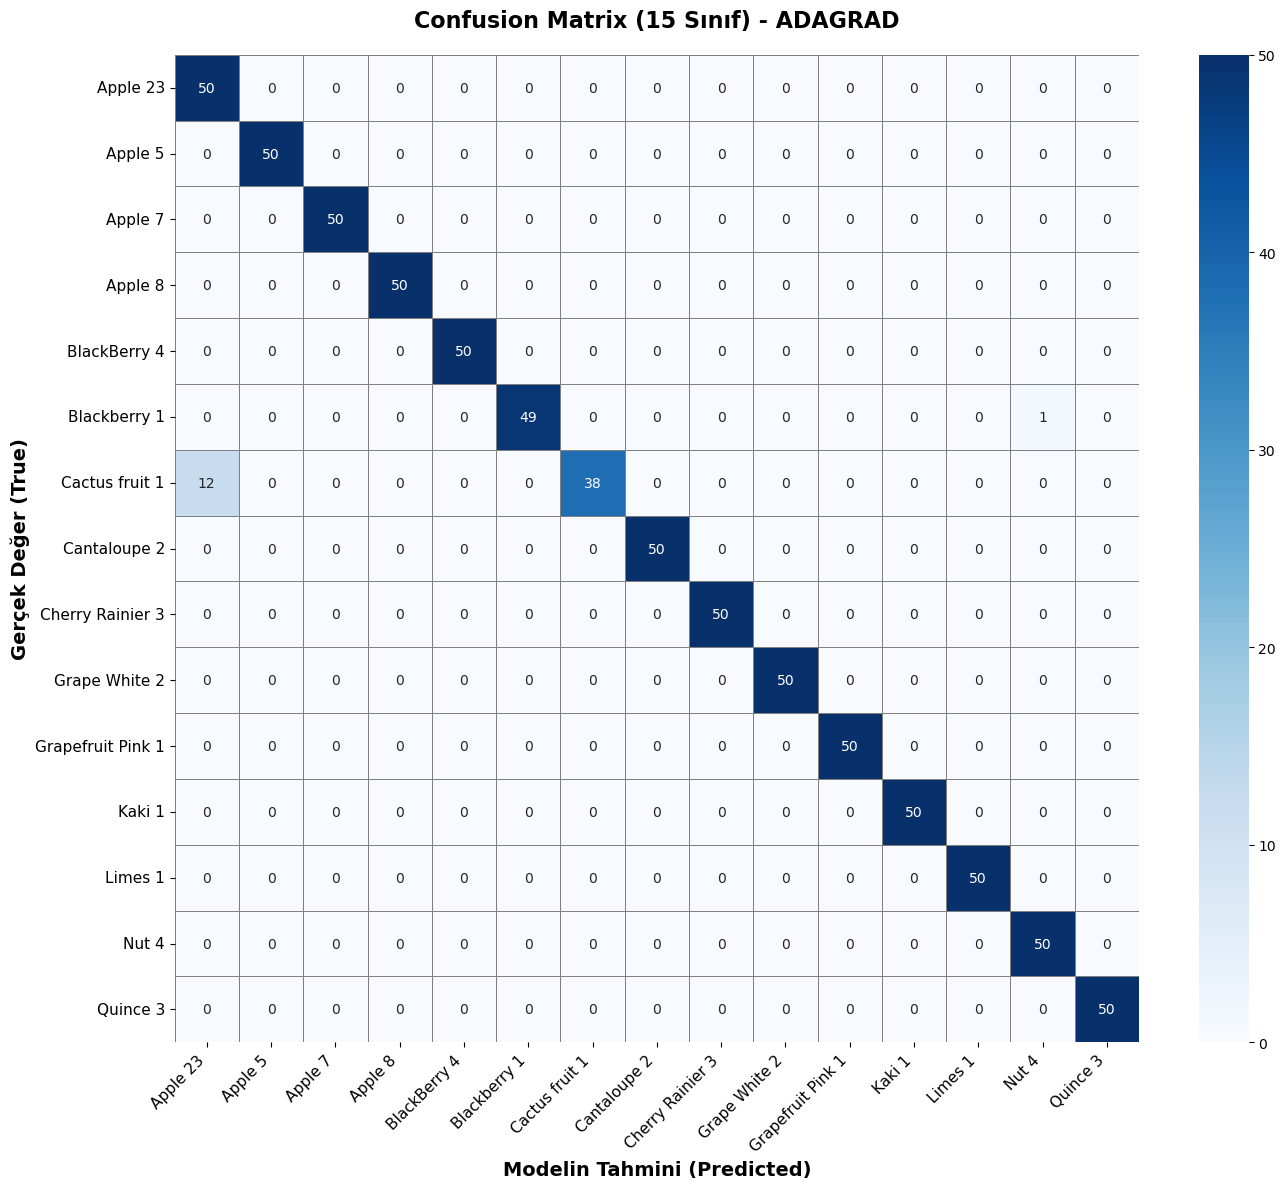


--- ADAGRAD İÇİN DETAYLI SINIFLANDIRMA RAPORU ---
                   precision    recall  f1-score   support

         Apple 23       0.81      1.00      0.89        50
          Apple 5       1.00      1.00      1.00        50
          Apple 7       1.00      1.00      1.00        50
          Apple 8       1.00      1.00      1.00        50
     BlackBerry 4       1.00      1.00      1.00        50
     Blackberry 1       1.00      0.98      0.99        50
   Cactus fruit 1       1.00      0.76      0.86        50
     Cantaloupe 2       1.00      1.00      1.00        50
 Cherry Rainier 3       1.00      1.00      1.00        50
    Grape White 2       1.00      1.00      1.00        50
Grapefruit Pink 1       1.00      1.00      1.00        50
           Kaki 1       1.00      1.00      1.00        50
          Limes 1       1.00      1.00      1.00        50
            Nut 4       0.98      1.00      0.99        50
         Quince 3       1.00      1.00      1.00        50

   

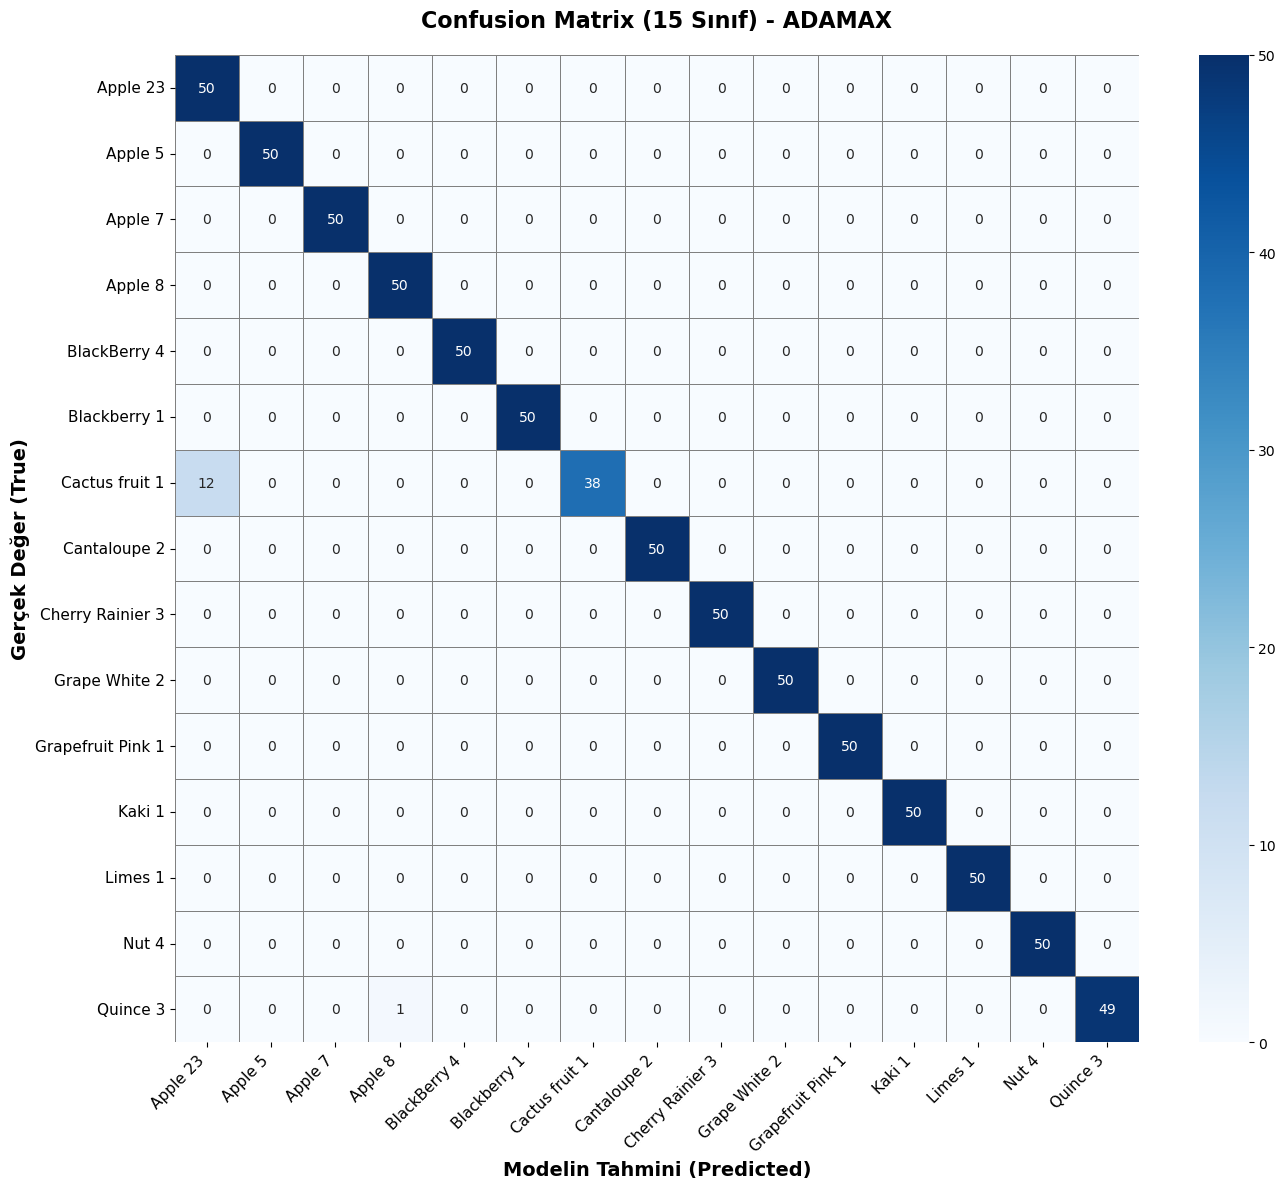


--- ADAMAX İÇİN DETAYLI SINIFLANDIRMA RAPORU ---
                   precision    recall  f1-score   support

         Apple 23       0.81      1.00      0.89        50
          Apple 5       1.00      1.00      1.00        50
          Apple 7       1.00      1.00      1.00        50
          Apple 8       0.98      1.00      0.99        50
     BlackBerry 4       1.00      1.00      1.00        50
     Blackberry 1       1.00      1.00      1.00        50
   Cactus fruit 1       1.00      0.76      0.86        50
     Cantaloupe 2       1.00      1.00      1.00        50
 Cherry Rainier 3       1.00      1.00      1.00        50
    Grape White 2       1.00      1.00      1.00        50
Grapefruit Pink 1       1.00      1.00      1.00        50
           Kaki 1       1.00      1.00      1.00        50
          Limes 1       1.00      1.00      1.00        50
            Nut 4       1.00      1.00      1.00        50
         Quince 3       1.00      0.98      0.99        50

    

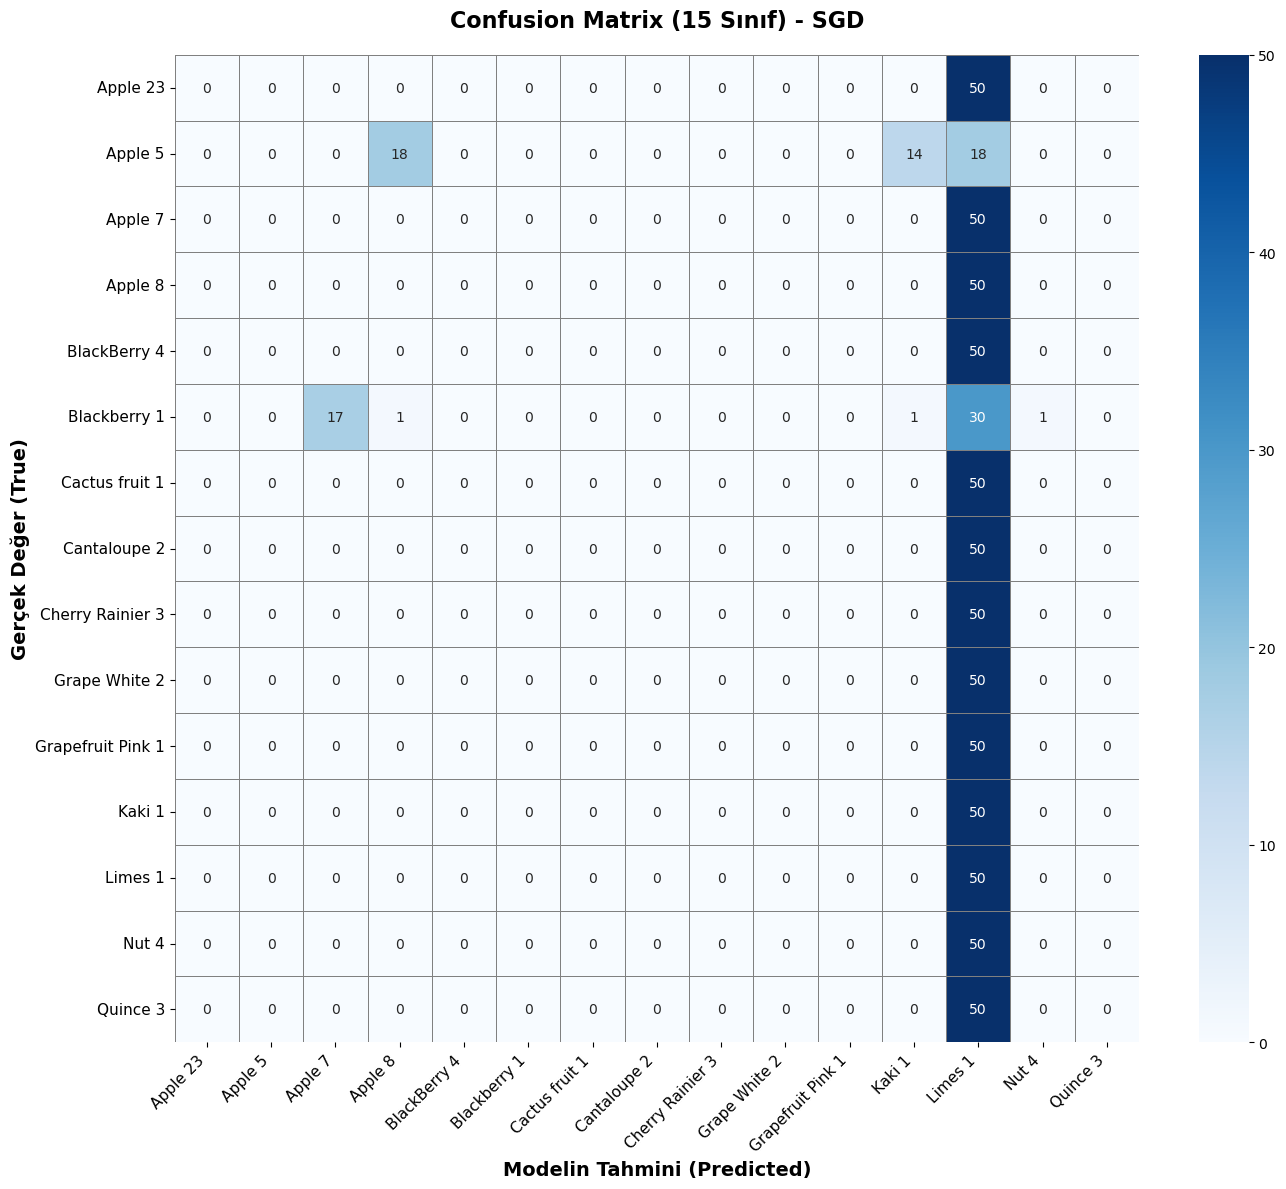


--- SGD İÇİN DETAYLI SINIFLANDIRMA RAPORU ---
                   precision    recall  f1-score   support

         Apple 23       0.00      0.00      0.00        50
          Apple 5       0.00      0.00      0.00        50
          Apple 7       0.00      0.00      0.00        50
          Apple 8       0.00      0.00      0.00        50
     BlackBerry 4       0.00      0.00      0.00        50
     Blackberry 1       0.00      0.00      0.00        50
   Cactus fruit 1       0.00      0.00      0.00        50
     Cantaloupe 2       0.00      0.00      0.00        50
 Cherry Rainier 3       0.00      0.00      0.00        50
    Grape White 2       0.00      0.00      0.00        50
Grapefruit Pink 1       0.00      0.00      0.00        50
           Kaki 1       0.00      0.00      0.00        50
          Limes 1       0.07      1.00      0.13        50
            Nut 4       0.00      0.00      0.00        50
         Quince 3       0.00      0.00      0.00        50

       

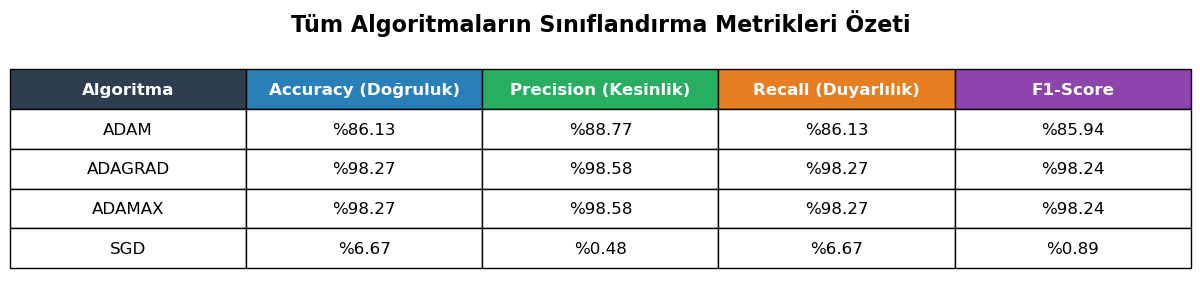

In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# SINIF İSİMLERİNİ ÇEK VE SIRALA (Grafik etiketleri için)
labels = list(val_gen_no_shuffle.class_indices.keys())
labels = sorted(labels, key=lambda x: val_gen_no_shuffle.class_indices[x])

#Özet tablo için metrikleri tutacağımız liste
summary_metrics = []

#Hafızaya aldığımız 4 modelin içinde dönüyoruz
for opt, model in models.items():
    print("\n" + "="*80)
    print(f"   {opt.upper()} ALGORİTMASI İÇİN CONFUSION MATRIX VE SINIFLANDIRMA RAPORU")
    print("="*80)

    # 1. JENERATÖRÜ SIFIRLA
    val_gen_no_shuffle.reset()

    # 2. TAHMİNLERİ AL
    print(f"{opt.upper()} ile test seti üzerinde tahminler alınıyor. Lütfen bekleyin...\n")
    Y_pred = model.predict(
        val_gen_no_shuffle,
        steps=len(val_gen_no_shuffle),
        verbose=0  # Ekrana çok fazla satır basmaması için 0 yapıldı
    )

    # 3. GERÇEK VE TAHMİN EDİLEN SINIFLARI EŞLEŞTİR
    y_pred = np.argmax(Y_pred, axis=1)
    y_true = val_gen_no_shuffle.classes

    # 4. CONFUSION MATRIX'İ HESAPLA
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(labels))
    )

    # 5. GÖRSELLEŞTİRME (ŞIK ISI HARİTASI)
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,       
        fmt='d',          
        cmap='Blues',     
        xticklabels=labels,
        yticklabels=labels,
        linewidths=.5,    
        linecolor='gray'
    )

    plt.xlabel("Modelin Tahmini (Predicted)", fontsize=14, fontweight='bold')
    plt.ylabel("Gerçek Değer (True)", fontsize=14, fontweight='bold')
    plt.title(f"Confusion Matrix (15 Sınıf) - {opt.upper()}", fontsize=16, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(rotation=0, fontsize=11)
    plt.tight_layout()
    plt.show()

    # 6. SINIFLANDIRMA RAPORU 
    print(f"\n--- {opt.upper()} İÇİN DETAYLI SINIFLANDIRMA RAPORU ---")
    print(classification_report(
        y_true,
        y_pred,
        target_names=labels,
        zero_division=0
    ))
    
    #Değerleri kodun içinden otomatik çekip hafızaya alıyoruz
    report_dict = classification_report(y_true, y_pred, target_names=labels, zero_division=0, output_dict=True)
    
    summary_metrics.append({
        'Algoritma': opt.upper(),
        'Accuracy (Doğruluk)': f"%{report_dict['accuracy']*100:.2f}",
        'Precision (Kesinlik)': f"%{report_dict['macro avg']['precision']*100:.2f}",
        'Recall (Duyarlılık)': f"%{report_dict['macro avg']['recall']*100:.2f}",
        'F1-Score': f"%{report_dict['macro avg']['f1-score']*100:.2f}"
    })

df_summary = pd.DataFrame(summary_metrics)

plt.figure(figsize=(12, 3))
plt.axis('off')

# Tabloyu oluştur ve renklendir
summary_table = plt.table(
    cellText=df_summary.values, 
    colLabels=df_summary.columns, 
    cellLoc='center', 
    loc='center', 
    colColours=['#2c3e50', '#2980b9', '#27ae60', '#e67e22', '#8e44ad'] # Başlık Renkleri
)

summary_table.auto_set_font_size(False)
summary_table.set_fontsize(12)
summary_table.scale(1.2, 2.5)


for key, cell in summary_table.get_celld().items():
    if key[0] == 0:
        cell.set_text_props(color='white', fontweight='bold')

plt.title("Tüm Algoritmaların Sınıflandırma Metrikleri Özeti", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

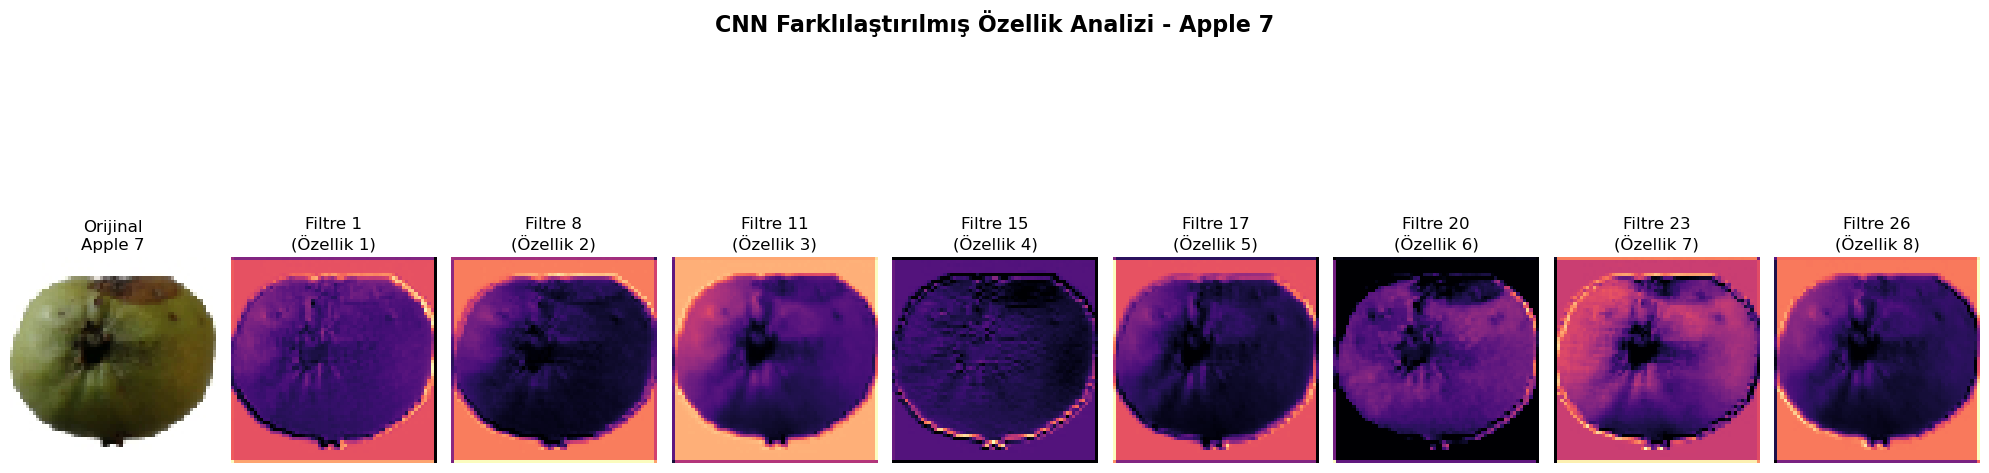

In [7]:
import os
import random
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
tf.get_logger().setLevel('ERROR')

# 1. RESİM SEÇME
test_folder = 'fruits_small_test'
random_class = random.choice(os.listdir(test_folder))
random_img_name = random.choice(os.listdir(os.path.join(test_folder, random_class)))
img_path = os.path.join(test_folder, random_class, random_img_name)

# 2. HAZIRLIK
img = tf.keras.utils.load_img(img_path, target_size=(64, 64))
img_tensor = tf.keras.utils.img_to_array(img) / 255.0
img_tensor = np.expand_dims(img_tensor, axis=0)

# 3. AKTİVASYONLARI ALMA
conv_layer = next((l for l in best_model.layers if isinstance(l, tf.keras.layers.Conv2D)), None)

if conv_layer:
    # Retracing uyarısını önlemek için modeli bir kez oluşturup tahmin alıyoruz
    activation_model = tf.keras.Model(inputs=best_model.inputs, outputs=conv_layer.output)
    
    # training=False ekleyerek uyarının önünü kesiyoruz
    activations = activation_model(img_tensor, training=False).numpy() 

    # 4. ÇEŞİTLİLİK VE AKTİVASYON FİLTRESİ
    num_filters = activations.shape[-1]
    useful_filters = []

    for i in range(num_filters):
        f_map = activations[0, :, :, i]
        # Ortalama aktivasyon eşiği (bomboşları elemek için)
        if np.mean(f_map) > 0.005: 
            useful_filters.append((i, f_map))

    # Görseldeki farklılıkları artırmak için atlama (step) mantığı
    step = len(useful_filters) // 8
    if step > 0:
        selected_indices = [useful_filters[i*step][0] for i in range(8)]
    else:
        selected_indices = [f[0] for f in useful_filters[:8]]

    # 5. GÖRSELLEŞTİRME
    plt.figure(figsize=(20, 6))
    
    # Orijinal
    plt.subplot(1, 9, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Orijinal\n{random_class}")

    # Seçilen Farklı Filtreler
    for i, idx in enumerate(selected_indices):
        plt.subplot(1, 9, i + 2)
        
        plt.imshow(activations[0, :, :, idx], cmap='magma') 
        plt.axis('off')
        plt.title(f'Filtre {idx+1}\n(Özellik {i+1})')

    plt.suptitle(f"CNN Farklılaştırılmış Özellik Analizi - {random_class}", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

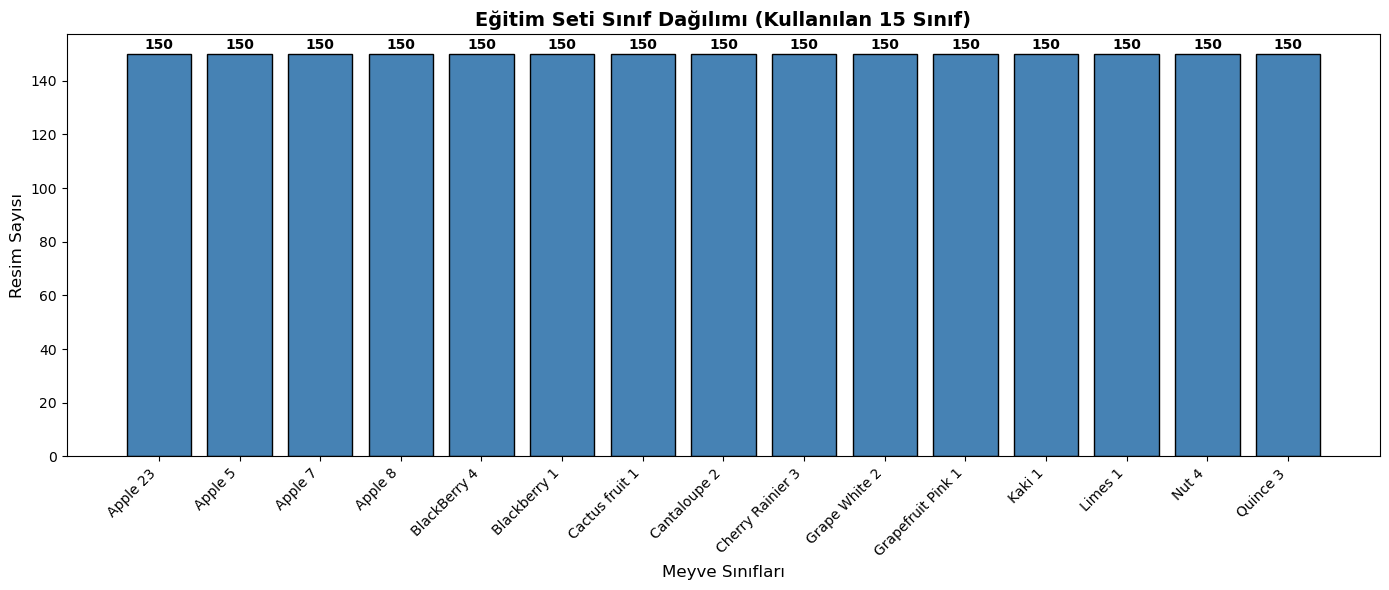

Eğitimde kullanılan final sınıf listesi: ['Apple 23', 'Apple 5', 'Apple 7', 'Apple 8', 'BlackBerry 4', 'Blackberry 1', 'Cactus fruit 1', 'Cantaloupe 2', 'Cherry Rainier 3', 'Grape White 2', 'Grapefruit Pink 1', 'Kaki 1', 'Limes 1', 'Nut 4', 'Quince 3']
Her sınıftaki resim sayısı: {150}


In [8]:
import os
import matplotlib.pyplot as plt

base_path = 'fruits_small_train'

# Klasörleri al ve sırala 
valid_classes = sorted(os.listdir(base_path))

actual_counts = []
for c in valid_classes:
    path = os.path.join(base_path, c)
    # Her klasördeki resim sayısını say
    actual_counts.append(len(os.listdir(path)))

#PLOT
plt.figure(figsize=(14, 6))

plt.bar(valid_classes, actual_counts, color='steelblue', edgecolor='black')

plt.title("Eğitim Seti Sınıf Dağılımı (Kullanılan 15 Sınıf)", fontsize=14, fontweight='bold')
plt.xlabel("Meyve Sınıfları", fontsize=12)
plt.ylabel("Resim Sayısı", fontsize=12)
plt.xticks(rotation=45, ha='right')


for i, count in enumerate(actual_counts):
    plt.text(i, count + 2, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Eğitimde kullanılan final sınıf listesi:", valid_classes)
print("Her sınıftaki resim sayısı:", set(actual_counts))

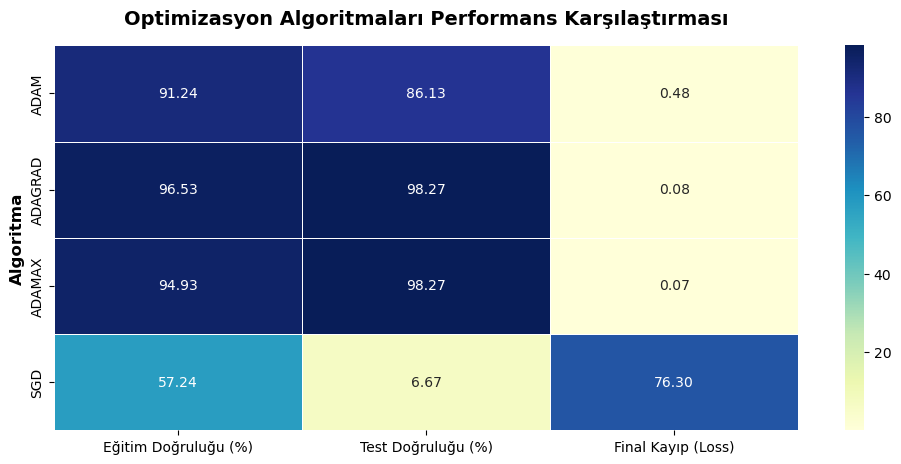

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

perf_data = []

for opt in optimizers:
    # Değerleri % formatına çeviriyoruz (Kayıp/Loss hariç)
    perf_data.append({
        'Algoritma': opt.upper(),
        'Eğitim Doğruluğu (%)': histories[opt].history['accuracy'][-1] * 100,
        'Test Doğruluğu (%)': histories[opt].history['val_accuracy'][-1] * 100,
        'Final Kayıp (Loss)': histories[opt].history['val_loss'][-1]
    })

df_perf = pd.DataFrame(perf_data).set_index('Algoritma')

plt.figure(figsize=(12, 5))
# fmt='.2f' yaparak virgülden sonra sadece 2 basamak gösteriyoruz
sns.heatmap(df_perf, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=.5)

plt.title("Optimizasyon Algoritmaları Performans Karşılaştırması", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Algoritma", fontsize=12, fontweight='bold')
plt.show()

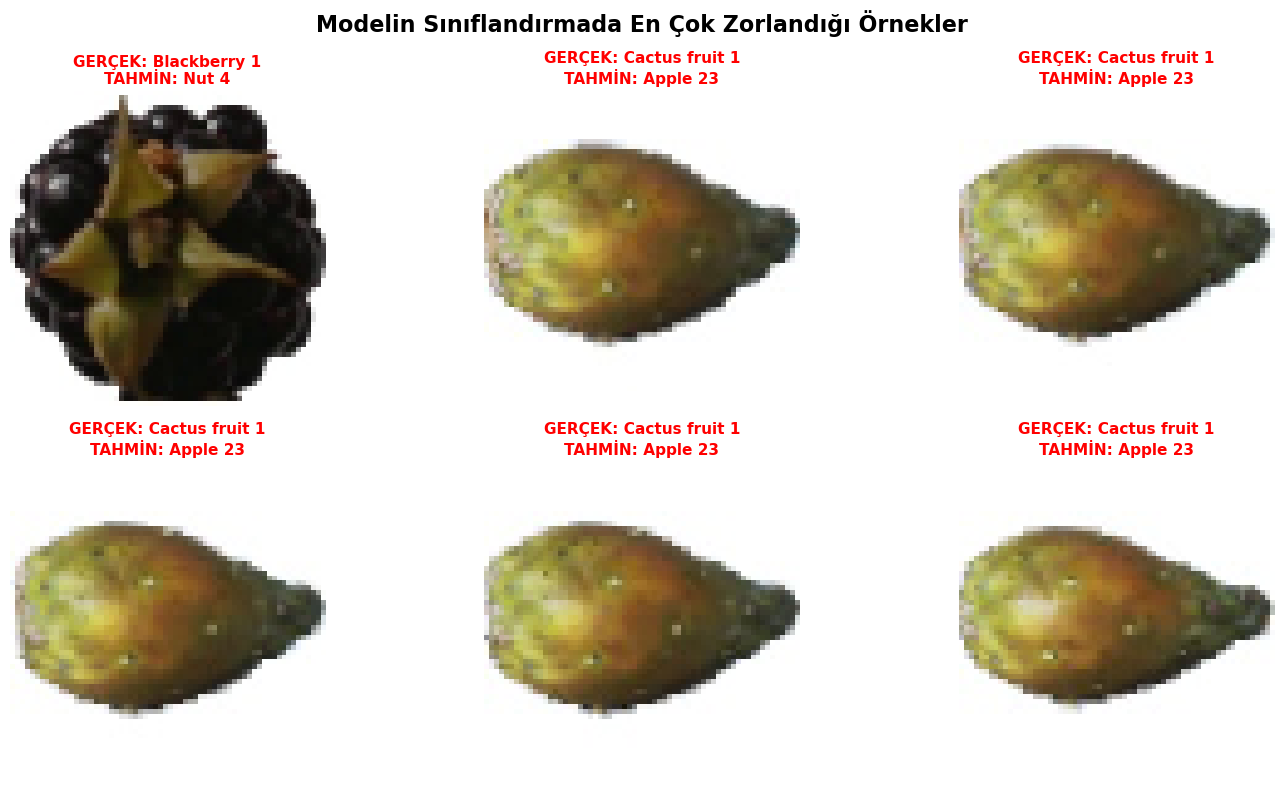

In [10]:
#MODELİN HATALI TAHMİNLERİ 
val_gen_no_shuffle.reset()

all_incorrect_images = []
all_incorrect_true = []
all_incorrect_pred = []

# Sınıf isimlerini jeneratörden alalım 
class_labels = list(val_gen_no_shuffle.class_indices.keys())

for i in range(len(val_gen_no_shuffle)):
    images, labels_batch = next(val_gen_no_shuffle)
    preds = best_model.predict(images, verbose=0)
    
    y_true_batch = np.argmax(labels_batch, axis=1)
    y_pred_batch = np.argmax(preds, axis=1)
    
    # Gerçekten birbirinden farklı olanları bul
    incorrect_idx = np.where(y_true_batch != y_pred_batch)[0]
    
    for idx in incorrect_idx:
        all_incorrect_images.append(images[idx])
        # Sayı dizisi değil, direkt meyve ismini ekliyoruz
        all_incorrect_true.append(class_labels[y_true_batch[idx]])
        all_incorrect_pred.append(class_labels[y_pred_batch[idx]])

# Görselleştirme
if len(all_incorrect_images) > 0:
    num_show = min(len(all_incorrect_images), 6)
    plt.figure(figsize=(15, 8))
    for i in range(num_show):
        plt.subplot(2, 3, i+1)
        plt.imshow(all_incorrect_images[i])
        # Temiz meyve isimlerini yazdırıyoruz
        plt.title(f"GERÇEK: {all_incorrect_true[i]}\nTAHMİN: {all_incorrect_pred[i]}", color='red', fontsize=11, fontweight='bold')
        plt.axis('off')
    plt.suptitle("Modelin Sınıflandırmada En Çok Zorlandığı Örnekler", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Tebrikler! Model tüm test setini hatasız tamamladı.")

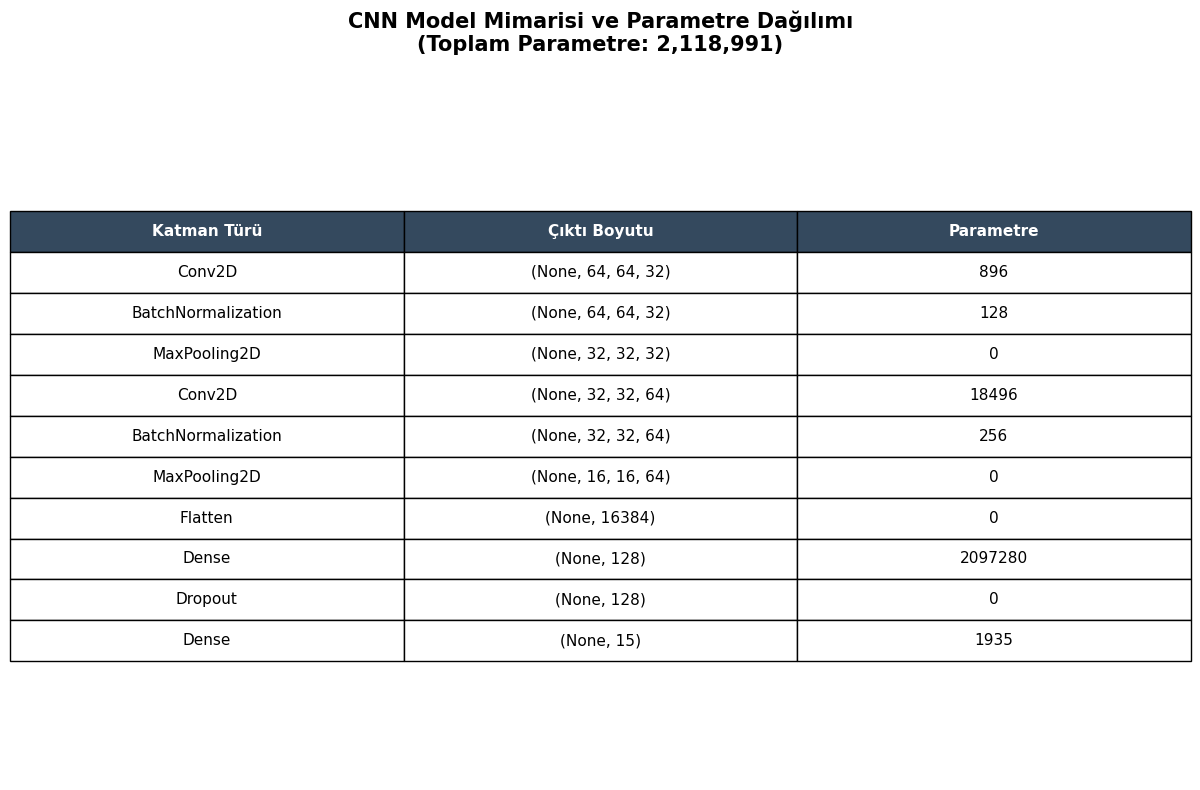

In [11]:
#GÖRSEL MİMARİ TABLOSU 
import pandas as pd
import matplotlib.pyplot as plt

layer_data = []
for layer in model.layers:
    layer_data.append({
        'Katman Türü': layer.__class__.__name__,
        'Çıktı Boyutu': str(layer.output.shape),
        'Parametre': layer.count_params()
    })

df_model = pd.DataFrame(layer_data)

# Görsel Tablo Oluşturma
plt.figure(figsize=(12, 8))
plt.axis('off')

# Tabloyu çizdirme
tbl = plt.table(
    cellText=df_model.values, 
    colLabels=df_model.columns, 
    cellLoc='center', 
    loc='center',
    colColours=['#34495e', '#34495e', '#34495e']
)


tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 2.2)


for key, cell in tbl.get_celld().items():
    if key[0] == 0:
        cell.set_text_props(color='white', fontweight='bold')

plt.title(f"CNN Model Mimarisi ve Parametre Dağılımı\n(Toplam Parametre: {model.count_params():,})", 
          fontsize=15, fontweight='bold', pad=30)

plt.tight_layout()
plt.show()

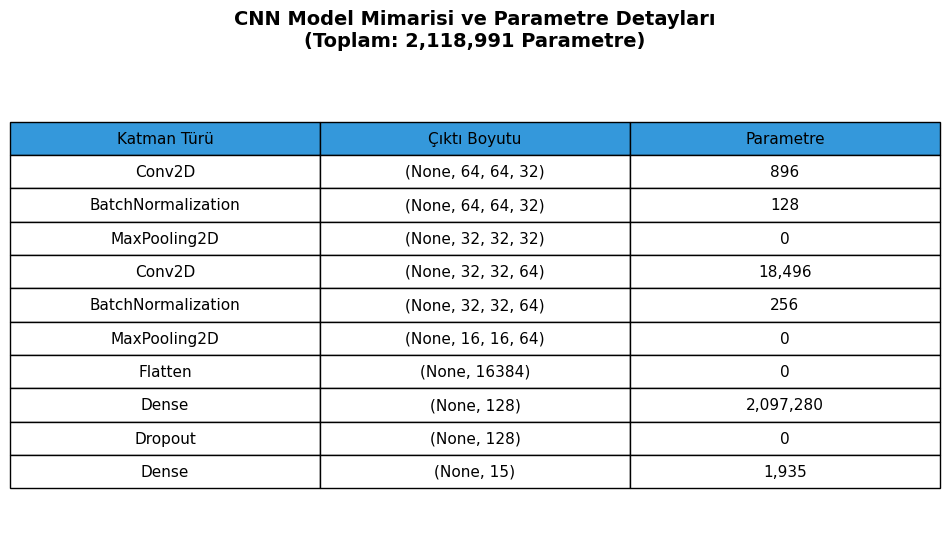

In [12]:
#GÖRSEL MİMARİ TABLOSU 
import pandas as pd


layers_data = []
for layer in model.layers:
    layers_data.append({
        'Katman Türü': layer.__class__.__name__,
        'Çıktı Boyutu': str(layer.output.shape),
        'Parametre': f"{layer.count_params():,}"
    })

df_mimari = pd.DataFrame(layers_data)

# Görsel tablo
plt.figure(figsize=(10, 6))
plt.axis('off')
tbl = plt.table(cellText=df_mimari.values, 
                colLabels=df_mimari.columns, 
                cellLoc='center', 
                loc='center',
                colColours=['#3498db', '#3498db', '#3498db'])

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 2) 

plt.title(f"CNN Model Mimarisi ve Parametre Detayları\n(Toplam: {model.count_params():,} Parametre)", 
          fontsize=14, pad=20, fontweight='bold')

plt.show()

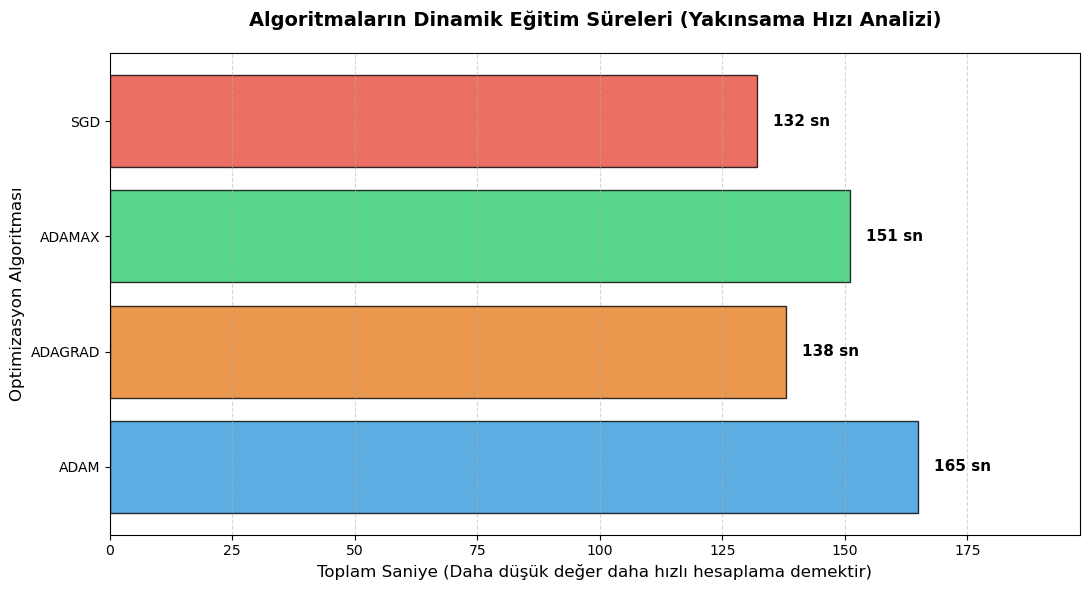

In [13]:
#DİNAMİK ALGORİTMA HIZ VE VERİMLİLİK ANALİZİ
import matplotlib.pyplot as plt

algoritmalar = list(execution_times.keys())
egitim_sureleri = list(execution_times.values())

plt.figure(figsize=(11, 6))
colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']

bars = plt.barh(algoritmalar, egitim_sureleri, color=colors, edgecolor='black', alpha=0.8)

for i, v in enumerate(egitim_sureleri):
    plt.text(v + (max(egitim_sureleri) * 0.02), i, f"{v} sn", va='center', fontweight='bold', fontsize=11)

plt.title("Algoritmaların Dinamik Eğitim Süreleri (Yakınsama Hızı Analizi)", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Toplam Saniye (Daha düşük değer daha hızlı hesaplama demektir)", fontsize=12)
plt.ylabel("Optimizasyon Algoritması", fontsize=12)

plt.xlim(0, max(egitim_sureleri) * 1.2)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

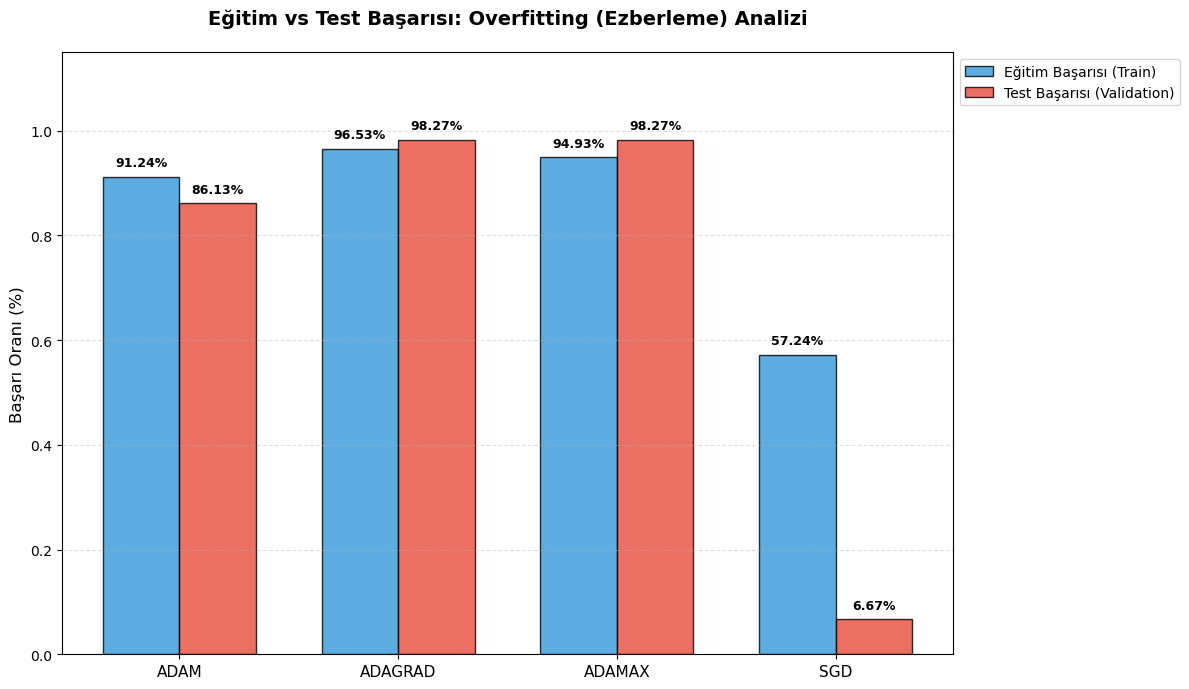


--- MODEL EZBERLEME (OVERFITTING) ANALİZ TABLOSU ---
 Eğitim Doğruluğu Test Doğruluğu Fark (Gap)
Algoritma   
ADAM 91.24% 86.13% 5.11%
ADAGRAD 96.53% 98.27% -1.73%
ADAMAX 94.93% 98.27% -3.33%
SGD 57.24% 6.67% 50.58%



In [14]:
#OVERFITTING (EZBERLEME) RİSK ANALİZİ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

overfit_summary = []
# histories sözlüğündeki gerçek değerleri çekiyoruz
for opt in optimizers:
    # Son epoch değerlerini alıyoruz
    train_acc = histories[opt].history['accuracy'][-1]
    val_acc = histories[opt].history['val_accuracy'][-1]
    gap = train_acc - val_acc 
    
    overfit_summary.append({
        'Algoritma': opt.upper(),
        'Eğitim Doğruluğu': train_acc,
        'Test Doğruluğu': val_acc,
        'Fark (Gap)': gap
    })

df_overfit = pd.DataFrame(overfit_summary).set_index('Algoritma')

plt.figure(figsize=(12, 7))
x = np.arange(len(optimizers))
width = 0.35

plt.bar(x - width/2, df_overfit['Eğitim Doğruluğu'], width, label='Eğitim Başarısı (Train)', color='#3498db', edgecolor='black', alpha=0.8)
plt.bar(x + width/2, df_overfit['Test Doğruluğu'], width, label='Test Başarısı (Validation)', color='#e74c3c', edgecolor='black', alpha=0.8)


for i, row in enumerate(df_overfit.itertuples()):
    plt.text(i - width/2, row._1 + 0.02, f'{row._1:.2%}', ha='center', fontsize=9, fontweight='bold')
    plt.text(i + width/2, row._2 + 0.02, f'{row._2:.2%}', ha='center', fontsize=9, fontweight='bold')

plt.ylabel('Başarı Oranı (%)', fontsize=12)
plt.title('Eğitim vs Test Başarısı: Overfitting (Ezberleme) Analizi', fontsize=14, fontweight='bold', pad=20)
plt.xticks(x, df_overfit.index, fontsize=11)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.ylim(0, 1.15) 

plt.tight_layout()
plt.show()

print("\n--- MODEL EZBERLEME (OVERFITTING) ANALİZ TABLOSU ---")

print(df_overfit.style.format("{:.2%}").to_string())

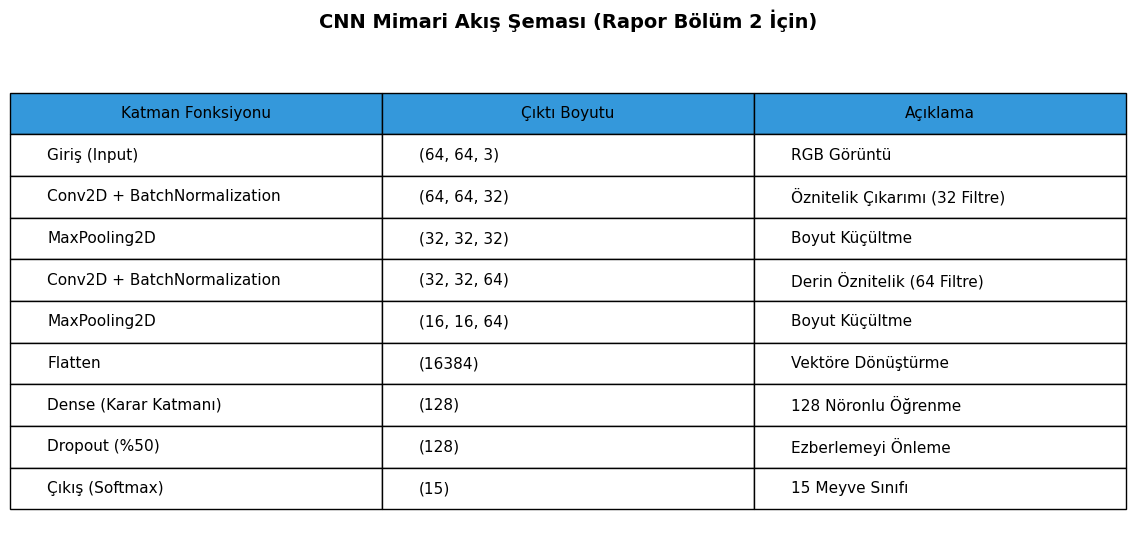

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Mimari Verisi
layers = [
    ["Giriş (Input)", "(64, 64, 3)", "RGB Görüntü"],
    ["Conv2D + BatchNormalization", "(64, 64, 32)", "Öznitelik Çıkarımı (32 Filtre)"],
    ["MaxPooling2D", "(32, 32, 32)", "Boyut Küçültme"],
    ["Conv2D + BatchNormalization", "(32, 32, 64)", "Derin Öznitelik (64 Filtre)"],
    ["MaxPooling2D", "(16, 16, 64)", "Boyut Küçültme"],
    ["Flatten", "(16384)", "Vektöre Dönüştürme"],
    ["Dense (Karar Katmanı)", "(128)", "128 Nöronlu Öğrenme"],
    ["Dropout (%50)", "(128)", "Ezberlemeyi Önleme"],
    ["Çıkış (Softmax)", "(15)", "15 Meyve Sınıfı"]
]

df_layer = pd.DataFrame(layers, columns=['Katman Fonksiyonu', 'Çıktı Boyutu', 'Açıklama'])

plt.figure(figsize=(12, 6))
plt.axis('off')
the_table = plt.table(cellText=df_layer.values, colLabels=df_layer.columns, 
                      loc='center', cellLoc='left', colColours=['#3498db']*3)
the_table.auto_set_font_size(False)
the_table.set_fontsize(11)
the_table.scale(1.2, 2.5)
plt.title("CNN Mimari Akış Şeması (Rapor Bölüm 2 İçin)", fontsize=14, fontweight='bold', pad=30)
plt.show()